# SK Hynix Defect Test Prediction — v2

**변경사항 (vs v1)**
- Step(C7)별 센서 집계 피처 추가
- Step 간 변화율(transition) 피처
- 핵심 센서 교호작용 피처
- C33 구간화 파생 변수

목표 RMSE: ~40

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '문제1(하)/'
ANS_DIR  = '문제1_하_answer/'
WF_ID    = 'C64'
TARGET   = 'C65'

## 1. 데이터 로드

In [2]:
train = pd.read_csv(DATA_DIR + 'train_data.csv')
valid_X = pd.read_csv(DATA_DIR + 'valid_X.csv')
test_X  = pd.read_csv(DATA_DIR + 'test_X.csv')

valid_Y_prob = pd.read_csv(DATA_DIR + 'valid_Y_problem.csv')
test_Y_prob  = pd.read_csv(DATA_DIR + 'test_Y_problem.csv')

valid_Y_ans = pd.read_csv(ANS_DIR + 'valid_Y_answer.csv')
test_Y_ans  = pd.read_csv(ANS_DIR + 'test_Y_answer.csv')

print(f"train: {train.shape}, valid_X: {valid_X.shape}, test_X: {test_X.shape}")

train: (123614, 65), valid_X: (20577, 64), test_X: (20510, 64)


## 2. 전처리 — 컬럼 정리

In [3]:
DROP_IDS      = ['C34', 'C35', 'C38']
DROP_LOT_IDS  = ['C20', 'C21', 'C22']
DROP_CONST    = ['C14', 'C24']
DROP_EXCLUDE  = ['C26', 'C28', 'C29', 'C37']
DROP_ALLNA    = ['C2', 'C13', 'C43', 'C47', 'C53', 'C55']
DROP_TIME_RAW = ['C10', 'C39', 'C40']

DROP_ALL = DROP_IDS + DROP_LOT_IDS + DROP_CONST + DROP_EXCLUDE + DROP_ALLNA + DROP_TIME_RAW

# valid/test 컬럼을 train 순서에 맞춤
train_cols_no_target = [c for c in train.columns if c != TARGET]
valid_X = valid_X[train_cols_no_target]
test_X  = test_X[train_cols_no_target]

# 사용할 수치형 센서 컬럼 식별
meta_cols = set([WF_ID] + DROP_ALL + ['C6', 'C7', 'C41', 'C33'])
SENSOR_COLS = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in meta_cols and c != TARGET]
print(f"FDC 센서 컬럼 수: {len(SENSOR_COLS)}")
print(f"센서 목록: {SENSOR_COLS}")

FDC 센서 컬럼 수: 36
센서 목록: ['C1', 'C3', 'C4', 'C5', 'C8', 'C9', 'C11', 'C12', 'C15', 'C16', 'C17', 'C18', 'C19', 'C25', 'C27', 'C31', 'C32', 'C36', 'C42', 'C44', 'C45', 'C46', 'C48', 'C49', 'C50', 'C51', 'C52', 'C54', 'C56', 'C57', 'C58', 'C59', 'C60', 'C61', 'C62', 'C63']


## 3. Feature Engineering — v2

**v1 대비 추가:**
1. Step별 센서 집계 (step-specific)
2. Step 간 전이 피처 (transition)
3. 핵심 센서 교호작용
4. C33 구간화

In [4]:
def compute_slope(series):
    y = series.dropna().values
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y), dtype=np.float64)
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def extract_wf_features_v2(df, has_target=True):
    groups = df.groupby(WF_ID)

    # ==============================
    # A. 글로벌 집계 (v1과 동일)
    # ==============================
    agg_df = groups[SENSOR_COLS].agg(['mean', 'std', 'min', 'max', 'median'])
    agg_df.columns = [f"{c}_{fn}" for c, fn in agg_df.columns]

    range_df = groups[SENSOR_COLS].apply(lambda x: x.max() - x.min())
    range_df.columns = [f"{c}_range" for c in SENSOR_COLS]

    delta_df = groups[SENSOR_COLS].apply(lambda x: x.iloc[-1] - x.iloc[0])
    delta_df.columns = [f"{c}_delta" for c in SENSOR_COLS]

    slope_df = groups[SENSOR_COLS].apply(lambda x: x.apply(compute_slope))
    slope_df.columns = [f"{c}_slope" for c in SENSOR_COLS]

    # ==============================
    # B. Step(C7)별 센서 집계 — NEW
    # ==============================
    # 각 step에서의 센서 mean/std를 별도 피처로 생성
    STEPS = sorted(df['C7'].unique())
    step_feat_list = []
    for step in STEPS:
        step_mask = df['C7'] == step
        step_data = df.loc[step_mask].groupby(WF_ID)[SENSOR_COLS]
        step_mean = step_data.mean()
        step_mean.columns = [f"{c}_step{step}_mean" for c in SENSOR_COLS]
        step_std = step_data.std()
        step_std.columns = [f"{c}_step{step}_std" for c in SENSOR_COLS]
        step_feat_list.append(step_mean)
        step_feat_list.append(step_std)

    step_feat = pd.concat(step_feat_list, axis=1)

    # ==============================
    # C. Step 간 전이 피처 — NEW
    # ==============================
    # 인접 step 간 센서 평균 변화량
    step_means = {}
    for step in STEPS:
        step_mask = df['C7'] == step
        sm = df.loc[step_mask].groupby(WF_ID)[SENSOR_COLS].mean()
        step_means[step] = sm

    trans_list = []
    for i in range(len(STEPS) - 1):
        s_from, s_to = STEPS[i], STEPS[i + 1]
        if s_from in step_means and s_to in step_means:
            diff = step_means[s_to].subtract(step_means[s_from], fill_value=0)
            diff.columns = [f"{c}_trans_{s_from}to{s_to}" for c in SENSOR_COLS]
            trans_list.append(diff)

    trans_feat = pd.concat(trans_list, axis=1) if trans_list else pd.DataFrame(index=groups.groups.keys())

    # ==============================
    # D. 핵심 센서 교호작용 — NEW
    # ==============================
    # 글로벌 mean 기준 교호작용
    key_sensors = ['C17', 'C12', 'C41', 'C33']
    key_sensors = [s for s in key_sensors if s in SENSOR_COLS or s in df.columns]

    interact_df = pd.DataFrame(index=agg_df.index)
    key_means = {}
    for s in key_sensors:
        col = f"{s}_mean"
        if col in agg_df.columns:
            key_means[s] = agg_df[col]
        else:
            key_means[s] = groups[s].mean()

    for i in range(len(key_sensors)):
        for j in range(i + 1, len(key_sensors)):
            s1, s2 = key_sensors[i], key_sensors[j]
            if s1 in key_means and s2 in key_means:
                interact_df[f"{s1}_x_{s2}"] = key_means[s1] * key_means[s2]
                # 비율 (0 나눗셈 방지)
                denom = key_means[s2].replace(0, np.nan)
                interact_df[f"{s1}_div_{s2}"] = key_means[s1] / denom

    # ==============================
    # E. C33 구간화 — NEW
    # ==============================
    c33_first = groups['C33'].first()
    c33_max = groups['C33'].max()

    pm_df = pd.DataFrame(index=groups.groups.keys())
    pm_df['C33_first'] = c33_first
    pm_df['C33_max'] = c33_max

    # 구간 bin (0~10, 10~50, 50~100, 100+)
    bins = [0, 10, 50, 100, float('inf')]
    labels_bin = [0, 1, 2, 3]
    pm_df['C33_bin'] = pd.cut(c33_first, bins=bins, labels=labels_bin, right=False).astype(float)

    # ==============================
    # F. 메타 + 범주형 (v1과 동일)
    # ==============================
    meta_df = pd.DataFrame(index=groups.groups.keys())
    meta_df['n_rows'] = groups.size()
    meta_df['C41_total'] = groups['C41'].max()

    # C6 비율
    if 'C6' in df.columns:
        c6_dum = pd.get_dummies(df[[WF_ID, 'C6']].set_index(WF_ID)['C6'], prefix='C6')
        c6_feat = c6_dum.groupby(level=0).mean()
    else:
        c6_feat = pd.DataFrame(index=groups.groups.keys())

    # C7 비율
    if 'C7' in df.columns:
        c7_dum = pd.get_dummies(df[[WF_ID, 'C7']].astype(str).set_index(WF_ID)['C7'], prefix='C7')
        c7_feat = c7_dum.groupby(level=0).mean()
    else:
        c7_feat = pd.DataFrame(index=groups.groups.keys())

    # ==============================
    # 결합
    # ==============================
    features = pd.concat([
        agg_df, range_df, delta_df, slope_df,  # 글로벌
        step_feat, trans_feat,                   # Step별 (NEW)
        interact_df,                             # 교호작용 (NEW)
        pm_df, meta_df,                          # PM + 메타
        c6_feat, c7_feat,                        # 범주형
    ], axis=1)
    features.index.name = WF_ID
    features = features.reset_index()

    if has_target:
        target_df = groups[TARGET].first().reset_index()
        features = features.merge(target_df, on=WF_ID)

    # NaN 처리 (step이 없는 WF에서 발생)
    features = features.fillna(0)

    return features

print("extract_wf_features_v2 정의 완료")

extract_wf_features_v2 정의 완료


## 4. 피처 추출 실행

In [5]:
%%time
print("Train 피처 추출 중...")
train_feat = extract_wf_features_v2(train, has_target=True)
print(f"  → {train_feat.shape}")

print("Valid 피처 추출 중...")
valid_feat = extract_wf_features_v2(valid_X, has_target=False)
print(f"  → {valid_feat.shape}")

print("Test 피처 추출 중...")
test_feat = extract_wf_features_v2(test_X, has_target=False)
print(f"  → {test_feat.shape}")

print(f"\nv1 대비 피처 수 변화: 315 → {train_feat.shape[1] - 2} (C64, C65 제외)")

Train 피처 추출 중...
  → (11939, 818)
Valid 피처 추출 중...
  → (1990, 817)
Test 피처 추출 중...
  → (1990, 817)

v1 대비 피처 수 변화: 315 → 816 (C64, C65 제외)
CPU times: total: 4min 52s
Wall time: 4min 53s


## 5. 피처/타깃 분리 & 정렬

In [6]:
feature_cols = [c for c in train_feat.columns if c not in [WF_ID, TARGET]]
common_cols = sorted(set(feature_cols) & set(valid_feat.columns) & set(test_feat.columns))
print(f"공통 피처 수: {len(common_cols)}")

X_train = train_feat[common_cols].values
y_train = train_feat[TARGET].values
wf_train = train_feat[WF_ID].values

X_valid = valid_feat[common_cols].values
X_test  = test_feat[common_cols].values
wf_valid = valid_feat[WF_ID].values
wf_test  = test_feat[WF_ID].values

valid_answer = valid_Y_ans.set_index('C64').loc[wf_valid, 'C65'].values
test_answer  = test_Y_ans.set_index('C64').loc[wf_test, 'C65'].values

baseline_rmse = np.sqrt(mean_squared_error(valid_answer, np.full_like(valid_answer, y_train.mean())))
print(f"베이스라인 RMSE (평균 예측): {baseline_rmse:.2f}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

공통 피처 수: 816
베이스라인 RMSE (평균 예측): 258.97
X_train: (11939, 816), y_train: (11939,)


## 6. GroupKFold CV + LightGBM 학습

In [7]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_estimators': 2000,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
}

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

wf_to_int = {wf: i for i, wf in enumerate(np.unique(wf_train))}
groups = np.array([wf_to_int[wf] for wf in wf_train])

oof_preds = np.zeros(len(X_train))
valid_preds_folds = np.zeros(len(X_valid))
test_preds_folds  = np.zeros(len(X_test))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(0),
        ]
    )

    oof_preds[val_idx] = model.predict(X_val)
    valid_preds_folds += model.predict(X_valid) / N_FOLDS
    test_preds_folds  += model.predict(X_test) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    fold_scores.append(fold_rmse)
    print(f"Fold {fold+1}: RMSE={fold_rmse:.4f}, best_iter={model.best_iteration_}")

oof_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
print(f"\nOOF RMSE (CV): {oof_rmse:.4f} ± {np.std(fold_scores):.4f}")

Fold 1: RMSE=63.0264, best_iter=121
Fold 2: RMSE=63.2018, best_iter=85
Fold 3: RMSE=62.2612, best_iter=106
Fold 4: RMSE=63.1510, best_iter=115
Fold 5: RMSE=63.9300, best_iter=112

OOF RMSE (CV): 63.1163 ± 0.5310


## 7. Valid / Test RMSE 평가

In [8]:
valid_rmse = np.sqrt(mean_squared_error(valid_answer, valid_preds_folds))
test_rmse  = np.sqrt(mean_squared_error(test_answer, test_preds_folds))

print("=" * 55)
print(f"{'v1 기준':>20} RMSE :  62.53 (Valid) / 61.15 (Test)")
print(f"{'v2 (현재)':>20} RMSE : {valid_rmse:.4f} (Valid) / {test_rmse:.4f} (Test)")
print(f"{'목표':>20} RMSE :  ~40")
print("=" * 55)

gap = abs(oof_rmse - valid_rmse)
print(f"\nCV↔Valid 격차: {gap:.4f}", "✓ 안정적" if gap < 30 else "⚠ 과적합 의심")

improvement = (62.53 - valid_rmse) / 62.53 * 100
print(f"v1 대비 개선: {improvement:+.2f}%")

               v1 기준 RMSE :  62.53 (Valid) / 61.15 (Test)
             v2 (현재) RMSE : 62.7188 (Valid) / 61.2469 (Test)
                  목표 RMSE :  ~40

CV↔Valid 격차: 0.3975 ✓ 안정적
v1 대비 개선: -0.30%


## 8. Feature Importance (Top 30)

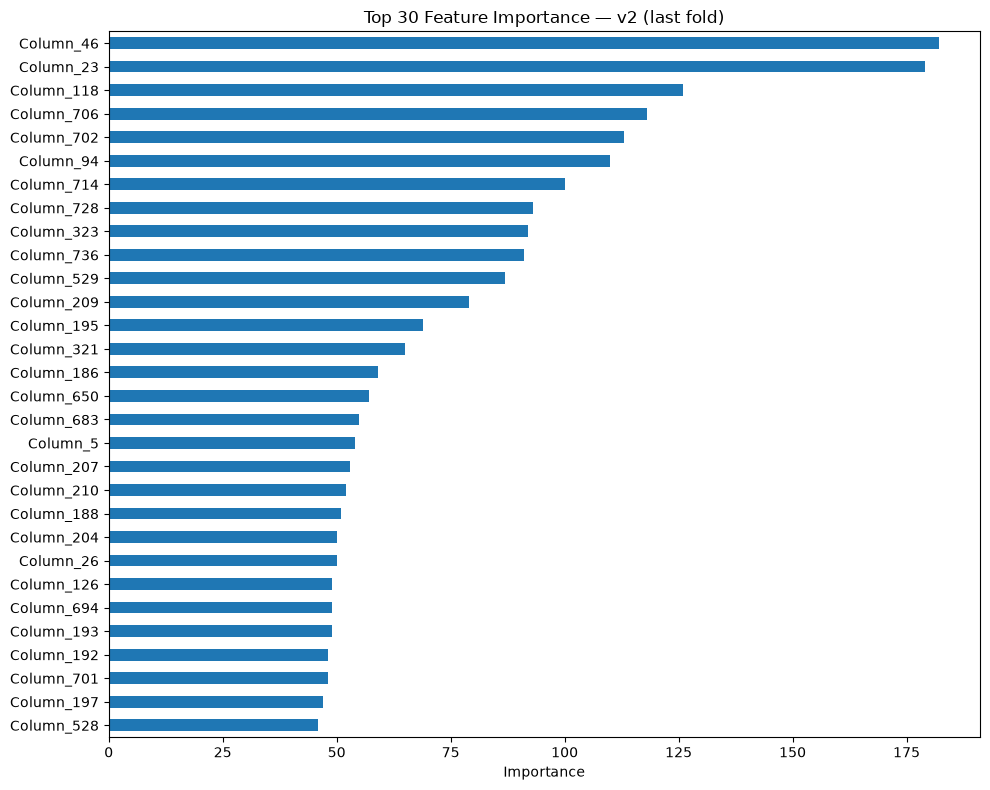


Top 30 중 v2 신규 피처: 0개


In [9]:
import matplotlib.pyplot as plt

imp = pd.Series(model.feature_importances_, index=model.feature_name_)
top30 = imp.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 8))
top30.sort_values().plot.barh(ax=ax)
ax.set_title('Top 30 Feature Importance — v2 (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# NEW vs OLD 피처 비교
new_feat_keywords = ['_step', '_trans_', '_x_', '_div_', 'C33_bin']
new_in_top30 = [f for f in top30.index if any(kw in f for kw in new_feat_keywords)]
print(f"\nTop 30 중 v2 신규 피처: {len(new_in_top30)}개")
for f in new_in_top30:
    print(f"  {f}: {imp[f]:.0f}")

## 9. 제출 파일 생성

In [10]:
valid_submit = valid_Y_prob.copy()
wf_to_pred_v = dict(zip(wf_valid, valid_preds_folds))
valid_submit['C65'] = valid_submit['C64'].map(wf_to_pred_v)
valid_submit.to_csv('valid_Y_submit.csv', index=False)

test_submit = test_Y_prob.copy()
wf_to_pred_t = dict(zip(wf_test, test_preds_folds))
test_submit['C65'] = test_submit['C64'].map(wf_to_pred_t)
test_submit.to_csv('test_Y_submit.csv', index=False)

print("제출 파일 저장 완료")
print(f"  valid_Y_submit.csv — {valid_submit.shape}")
print(f"  test_Y_submit.csv  — {test_submit.shape}")

제출 파일 저장 완료
  valid_Y_submit.csv — (1990, 2)
  test_Y_submit.csv  — (1990, 2)


## 10. 일반화 점검

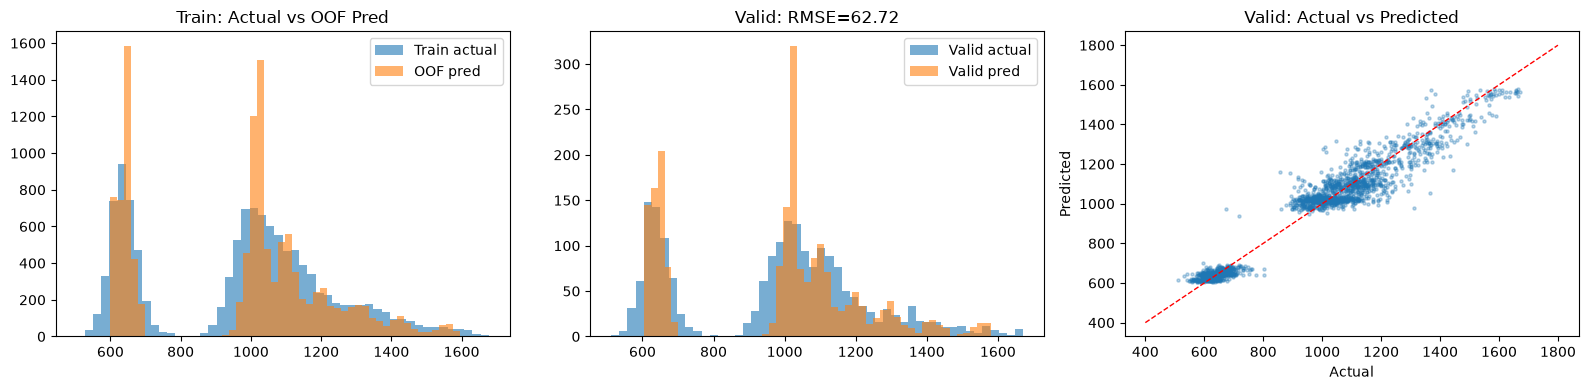

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=50, alpha=0.6, label='Train actual')
axes[0].hist(oof_preds, bins=50, alpha=0.6, label='OOF pred')
axes[0].set_title('Train: Actual vs OOF Pred')
axes[0].legend()

axes[1].hist(valid_answer, bins=50, alpha=0.6, label='Valid actual')
axes[1].hist(valid_preds_folds, bins=50, alpha=0.6, label='Valid pred')
axes[1].set_title(f'Valid: RMSE={valid_rmse:.2f}')
axes[1].legend()

axes[2].scatter(valid_answer, valid_preds_folds, s=5, alpha=0.3)
axes[2].plot([400, 1800], [400, 1800], 'r--', lw=1)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Valid: Actual vs Predicted')

plt.tight_layout()
plt.show()